# **EV Conjoint Analysis for Urban Commuters**

## **Problem Statement:**

As India's electric vehicle market(Scooters) rapidly expands, manufacturers face a critical question: What features do urban commuters actually value when purchasing an EV?

Understanding these preferences is essential for:

1.Product development optimization

2.Effective marketing positioning

3.Strategic pricing decisions

4.Market entry strategies for new players.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
#Loading the data
df = pd.read_excel("/content/EvConjoint.xlsx")
df.head(10)

,Profile,Range per charge,Charge Capacity,Price,Brand,Individual_1,Individual_2,Individual_3,Individual_4,Individual_5,...,Individual_11,Individual_12,Individual_13,Individual_14,Individual_15,Individual_16,Individual_17,Individual_18,Individual_19,Individual_20
0,P1,80 km,Standard,250k,Startup,10,9,10,10,9,...,5,10,10,10,10,10,4,10,10,3
1,P2,80 km,Fast,90k,Established,6,5,6,8,8,...,9,8,6,9,7,2,10,4,5,10
2,P3,120 km,Standard,120k,Startup,7,8,5,9,7,...,8,6,5,6,6,6,8,5,8,8
3,P4,120 km,Fast,120k,Established,3,6,4,3,6,...,4,4,4,5,5,7,2,7,4,9
4,P5,120 km,Rapid,250k,Startup,9,4,8,6,10,...,6,7,8,7,8,9,6,9,7,5
5,P6,180 km,Standard,120k,Established,4,3,2,5,5,...,7,3,2,3,2,3,9,8,3,7
6,P7,180 km,Fast,250k,Startup,5,10,7,4,4,...,3,5,7,2,9,5,3,1,6,6
7,P8,180 km,Rapid,120k,Established,1,2,1,2,3,...,10,1,1,1,1,4,4,3,1,4
8,P9,80 km,Rapid,120k,Startup,8,7,9,7,2,...,4,9,9,8,4,8,5,6,9,1
9,P10,120 km,Rapid,90k,Established,2,1,3,1,1,...,1,2,3,4,3,1,1,2,2,2


In [ ]:
#Looking at the datatype variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Profile           10 non-null     object
 1   Range per charge  10 non-null     object
 2   Charge Capacity   10 non-null     object
 3   Price             10 non-null     object
 4   Brand             10 non-null     object
 5   Individual_1      10 non-null     int64 
 6   Individual_2      10 non-null     int64 
 7   Individual_3      10 non-null     int64 
 8   Individual_4      10 non-null     int64 
 9   Individual_5      10 non-null     int64 
 10  Individual_6      10 non-null     int64 
 11  Individual_7      10 non-null     int64 
 12  Individual_8      10 non-null     int64 
 13  Individual_9      10 non-null     int64 
 14  Individual_10     10 non-null     int64 
 15  Individual_11     10 non-null     int64 
 16  Individual_12     10 non-null     int64 
 17  Individual_13     1

In [ ]:
#Converting the Wide format to long format and reversing the scale.
#1--best and 10-- worst but when we reverse it says 10-- best and 1-- worst
df = df.melt(id_vars=['Profile', 'Range per charge', 'Charge Capacity', 'Price', 'Brand'], var_name='resp', value_name='Value')
df['Value'] = 11-df['Value']
dfobs = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Profile           200 non-null    object
 1   Range per charge  200 non-null    object
 2   Charge Capacity   200 non-null    object
 3   Price             200 non-null    object
 4   Brand             200 non-null    object
 5   resp              200 non-null    object
 6   Value             200 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 11.1+ KB


In [ ]:
df = df.sort_values(by='resp')

In [ ]:
df.head(20)

,Profile,Range per charge,Charge Capacity,Price,Brand,resp,Value
0,P1,80 km,Standard,250k,Startup,Individual_1,1
8,P9,80 km,Rapid,120k,Startup,Individual_1,3
7,P8,180 km,Rapid,120k,Established,Individual_1,10
6,P7,180 km,Fast,250k,Startup,Individual_1,6
5,P6,180 km,Standard,120k,Established,Individual_1,7
9,P10,120 km,Rapid,90k,Established,Individual_1,9
3,P4,120 km,Fast,120k,Established,Individual_1,8
2,P3,120 km,Standard,120k,Startup,Individual_1,4
1,P2,80 km,Fast,90k,Established,Individual_1,5
4,P5,120 km,Rapid,250k,Startup,Individual_1,2


Range per charge
80 km     4.050000
120 km    5.825000
180 km    6.533333
Name: Value, dtype: float64


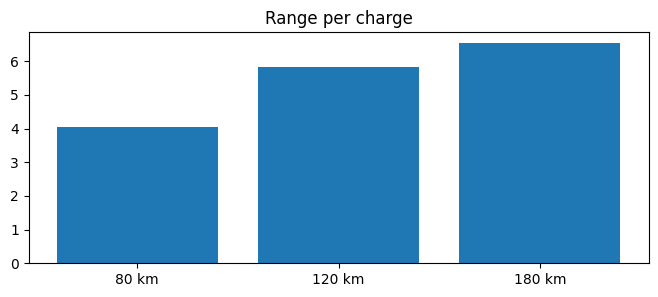

Charge Capacity
Standard    4.533333
Fast        5.466667
Rapid       6.262500
Name: Value, dtype: float64


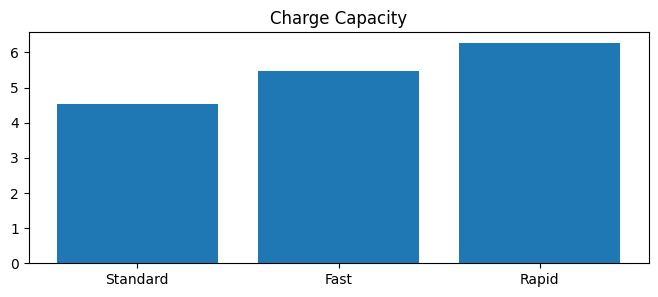

Price
250k    4.116667
120k    5.980000
90k     6.400000
Name: Value, dtype: float64


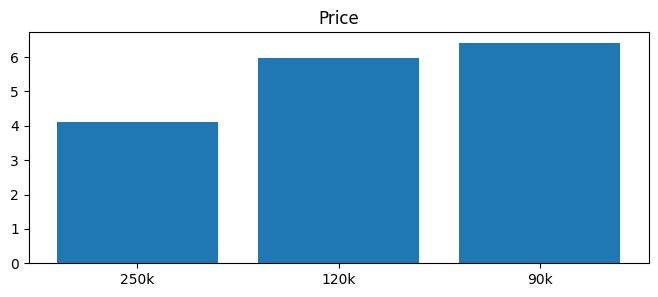

Brand
Startup        4.34
Established    6.67
Name: Value, dtype: float64


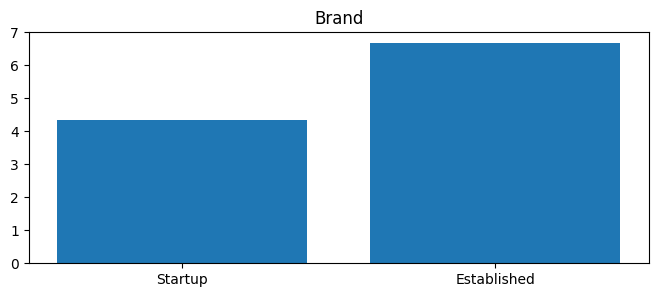

In [ ]:
#Looking at the distribution of the attributes
cols = ['Range per charge', 'Charge Capacity', 'Price', 'Brand']
for col in cols:
    df3 = df.groupby(col)['Value'].agg('mean').sort_values()
    print(df3)
    plt.figure(figsize=(8,3))
    plt.title(col)
    plt.bar(x=df3.index, height=df3.values)
    plt.show()

In [ ]:
#Converting the atrribute levels into dummy variables
df2 = pd.get_dummies(df, columns=['Range per charge', 'Charge Capacity', 'Price', 'Brand'], drop_first=True, dtype=float)

In [ ]:
df2.head(2)

,Profile,resp,Value,Range per charge_180 km,Range per charge_80 km,Charge Capacity_Rapid,Charge Capacity_Standard,Price_250k,Price_90k,Brand_Startup
0,P1,Individual_1,1,0.0,1.0,0.0,1.0,1.0,0.0,1.0
8,P9,Individual_1,3,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
#Building a Regression Model
import statsmodels.api as sm

y = df2['Value']
X = df2.drop(['Profile', 'resp', 'Value'], axis=1)
X['const'] = 1

lir = sm.OLS(y, X).fit()
lir.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Value   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     11.18
Date:                Thu, 22 Jan 2026   Prob (F-statistic):           7.68e-12
Time:                        17:55:23   Log-Likelihood:                -460.02
No. Observations:                 200   AIC:                             936.0
Df Residuals:                     192   BIC:                             962.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Range per charge_180 km      0.9849      0.490      2.011      0.046       0.019       1.951
Range per charge_80 km      -1.4105      0.445     -3.173      0.002      -2.287      -0.534
Charge Capacity_Rapid        0.8728      0.441      1.978      0.049       0.002       1.743
Charge Capacity_Standard    -0.4300      0.493     -0.873      0.384      -1.402       0.542
Price_250k                  -1.0479      0.547     -1.916      0.057      -2.127       0.031
Price_90k                    0.6230      0.631      0.988      0.325      -0.621       1.867
Brand_Startup               -0.8870      0.631     -1.406      0.161      -2.131       0.357
const                        6.0458      0.535     11.295      0.000       4.990       7.102
==============================================================================
Omnibus:                        0.834   Durbin-Watson:                   2.148
Prob(Omnibus):                  0.659   Jarque-Bera (JB):                0.789
Skew:                          -0.152   Prob(JB):                        0.674
Kurtosis:                       2.959   Cond. No.                         7.59
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
lp = lir.params
pars = pd.DataFrame({'var':lp.index, 'coeft':lp.values})
pars

,var,coeft
0,Range per charge_180 km,0.984884
1,Range per charge_80 km,-1.410465
2,Charge Capacity_Rapid,0.872791
3,Charge Capacity_Standard,-0.430000
4,Price_250k,-1.047907
5,Price_90k,0.623023
6,Brand_Startup,-0.886977
7,const,6.045814


In [ ]:
dfg = pd.get_dummies(df.loc[:, [ 'Range per charge', 'Charge Capacity', 'Price', 'Brand']],
                     columns=['Range per charge', 'Charge Capacity', 'Price', 'Brand'])
cols = list(dfg.columns)

df3 = pd.DataFrame()
df3['var'] = cols
cols

['Range per charge_120 km',
 'Range per charge_180 km',
 'Range per charge_80 km',
 'Charge Capacity_Fast',
 'Charge Capacity_Rapid',
 'Charge Capacity_Standard',
 'Price_120k',
 'Price_250k',
 'Price_90k',
 'Brand_Established',
 'Brand_Startup']

In [ ]:
#Joining the Dataframe of dummy variables and dummy variables with base one
df3 = df3.merge(pars, on='var', how='left')
df3 = df3.fillna(0)

In [ ]:
#Calculating the atrribute importance scores from the part-worth utilities
df3['attrib'] = df3['var'].str.split('_', n=1, expand=True)[0]
df3['factors'] = df3['var'].str.split('_', n=1, expand=True)[1]

In [ ]:
df3

,var,coeft,attrib,factors
0,Range per charge_120 km,0.000000,Range per charge,120 km
1,Range per charge_180 km,0.984884,Range per charge,180 km
2,Range per charge_80 km,-1.410465,Range per charge,80 km
3,Charge Capacity_Fast,0.000000,Charge Capacity,Fast
4,Charge Capacity_Rapid,0.872791,Charge Capacity,Rapid
5,Charge Capacity_Standard,-0.430000,Charge Capacity,Standard
6,Price_120k,0.000000,Price,120k
7,Price_250k,-1.047907,Price,250k
8,Price_90k,0.623023,Price,90k
9,Brand_Established,0.000000,Brand,Established


In [ ]:
#Seeing the most important attribute
attrib = df3.groupby('attrib')['coeft'].agg(['min', 'max'])
attrib['imp'] = attrib['max'] - attrib['min']
attrib['imp%'] = attrib['imp']*100/(attrib['imp'].sum())
attrib = attrib.sort_values(['imp%'],ascending=False)
attrib

,min,max,imp,imp%
attrib,,,,
Range per charge,-1.410465,0.984884,2.395349,38.288539
Price,-1.047907,0.623023,1.670930,26.709044
Charge Capacity,-0.430000,0.872791,1.302791,20.824505
Brand,-0.886977,0.000000,0.886977,14.177912


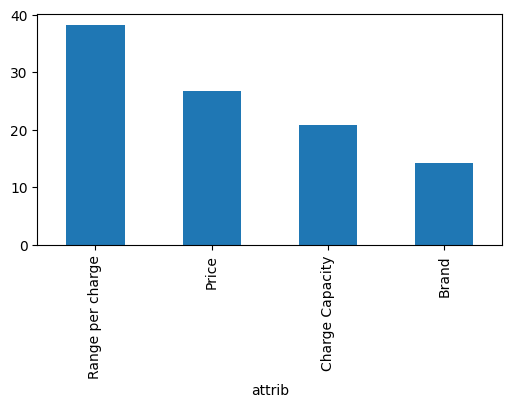

In [ ]:
attrib['imp%'].plot.bar(figsize=(6,3))
plt.show()

So, from the above we know that utilities are relative and range per charge is the bigger impact on choice and brand is having less impact when compared.

# **Full Factorail Design:**
A full factorial design in conjoint analysis tests every possible combination of product attributes and levels to measure their individual and interactive effects on consumer preference. It ensures high-precision estimation of utilities but is only practical for studies with a limited number of attributes, as the number of combinations grows exponentially

In [ ]:
#Generating a full factorial design.
list1 = ['80 km', '120 km', '180 km']
list2 = ['Standard', 'Fast', 'Rapid']
list3 = ['90k', '120k', '250k']
list4 = ['Startup', 'Established']

factors = [[i, j, k, l] for i in list1
                 for j in list2
                 for k in list3
                 for l in list4]

In [ ]:
#We are generating every possible products profile by combining all the attribute levels.
df = pd.DataFrame(factors, columns=[ 'Range per charge', 'Charge Capacity', 'Price', 'Brand'])
df.head()

,Range per charge,Charge Capacity,Price,Brand
0,80 km,Standard,90k,Startup
1,80 km,Standard,90k,Established
2,80 km,Standard,120k,Startup
3,80 km,Standard,120k,Established
4,80 km,Standard,250k,Startup


In [ ]:
#Total product utilites are calculated
df4 = df3.loc[:, ['factors', 'coeft']]

for fs in ['Range per charge', 'Charge Capacity', 'Price', 'Brand']:
    df5 = df4.rename(columns = {'coeft': str('coef_'+fs),'factors':fs})
    df = df.merge(df5, on=fs)

print(df.head())

  Range per charge Charge Capacity Price        Brand  coef_Range per charge  \
0            80 km        Standard   90k      Startup              -1.410465   
1            80 km        Standard   90k  Established              -1.410465   
2            80 km        Standard  120k      Startup              -1.410465   
3            80 km        Standard  120k  Established              -1.410465   
4            80 km        Standard  250k      Startup              -1.410465   

   coef_Charge Capacity  coef_Price  coef_Brand  
0                 -0.43    0.623023   -0.886977  
1                 -0.43    0.623023    0.000000  
2                 -0.43    0.000000   -0.886977  
3                 -0.43    0.000000    0.000000  
4                 -0.43   -1.047907   -0.886977  


In [ ]:
#Conjoint market simulation
#Taking part-worth utilities and turn them into total utility per product and choice probabilities
#Lastly, calculate the market share
df['Tot_utils'] = df.loc[:,['coef_Range per charge', 'coef_Charge Capacity', 'coef_Price', 'coef_Brand']].sum(axis=1)
df['exp_tot_util'] = np.exp(0.8*df['Tot_utils'])
Tot_Exp_Util = df['exp_tot_util'].sum()
df['Mkt Share'] = df['exp_tot_util'] /Tot_Exp_Util

In [ ]:
#Arranging in Descending order to see the most preferred by market share.
df = df.sort_values('Tot_utils', ascending=False)
df.head()

,Range per charge,Charge Capacity,Price,Brand,coef_Range per charge,coef_Charge Capacity,coef_Price,coef_Brand,Tot_utils,exp_tot_util,Mkt Share
49,180 km,Rapid,90k,Established,0.984884,0.872791,0.623023,0.000000,2.480698,7.275832,0.120931
51,180 km,Rapid,120k,Established,0.984884,0.872791,0.000000,0.000000,1.857674,4.419999,0.073465
43,180 km,Fast,90k,Established,0.984884,0.000000,0.623023,0.000000,1.607907,3.619463,0.060159
48,180 km,Rapid,90k,Startup,0.984884,0.872791,0.623023,-0.886977,1.593721,3.578618,0.059480
31,120 km,Rapid,90k,Established,0.000000,0.872791,0.623023,0.000000,1.495814,3.309017,0.054999
